# Cell 1 — Mount Drive & Verify Folder

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/dl-energy-forecasting')

import os
print(os.listdir('/content/drive/MyDrive/dl-energy-forecasting'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.git', '.gitignore', 'README.md', 'data', 'models', 'requirements.txt', 'train.py', 'utils', 'config.yaml']


# Cell 2 — GPU Check

In [2]:
import torch
print('GPU available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0))

GPU available: True
Device: Tesla T4


In [3]:
import yaml
import pickle
import torch
import numpy as np
import json
from torch.utils.data import DataLoader, TensorDataset
from utils.seed import set_seed
from utils.trainer import train_model
from utils.metrics import compute_all_metrics
from models.lstm import BiLSTMForecaster

BASE = '/content/drive/MyDrive/dl-energy-forecasting'

# load config
with open(f'{BASE}/config.yaml') as f:
    config = yaml.safe_load(f)

set_seed(config['seed'])
device = torch.device('cuda')
print(f"Training on: {device}")

# load data
with open(f'{BASE}/data/processed.pkl', 'rb') as f:
    data = pickle.load(f)

train_df    = data['train']
val_df      = data['val']
test_df     = data['test']
feat_cols   = data['feature_cols']
target_cols = data['target_cols']

# build windows
def make_windows(df, feature_cols, target_cols, lookback, horizon):
    d = df[feature_cols].values
    t = df[target_cols].values
    X, Y = [], []
    for i in range(len(d) - lookback - horizon + 1):
        X.append(d[i:i+lookback])
        Y.append(t[i+lookback:i+lookback+horizon].T)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

L, H = config['lookback'], config['horizon']
X_train, Y_train = make_windows(train_df, feat_cols, target_cols, L, H)
X_val,   Y_val   = make_windows(val_df,   feat_cols, target_cols, L, H)
X_test,  Y_test  = make_windows(test_df,  feat_cols, target_cols, L, H)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

train_loader = DataLoader(TensorDataset(
    torch.tensor(X_train), torch.tensor(Y_train)),
    batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(TensorDataset(
    torch.tensor(X_val), torch.tensor(Y_val)),
    batch_size=config['batch_size'])
test_loader = DataLoader(TensorDataset(
    torch.tensor(X_test), torch.tensor(Y_test)),
    batch_size=config['batch_size'])

Training on: cuda
Train: (26113, 168, 15), Val: (8569, 168, 15), Test: (12937, 168, 15)


# Cell 3 — LSTM Training

In [4]:
import torch
import torch.nn as nn
import numpy as np

print("--- Training Baseline BiLSTM (Standard MSE) ---")

# 1. Define Standard Point-Forecasting Baseline
class BaselineBiLSTM(nn.Module):
    def __init__(self, input_size, n_targets, horizon, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, bidirectional=True
        )
        # Bidirectional doubles the hidden size
        self.fc = nn.Linear(hidden_size * 2, horizon * n_targets)
        self.horizon = horizon
        self.n_targets = n_targets

    def forward(self, x):
        # x shape: (B, 168, 15)
        lstm_out, _ = self.lstm(x)
        # Extract the last timestep to make the prediction
        last_out = lstm_out[:, -1, :]
        out = self.fc(last_out)
        # Reshape to match your target 'y' shape: (B, 3 targets, 24 horizon)
        return out.reshape(x.shape[0], self.n_targets, self.horizon)

# 2. Initialize
lstm_model = BaselineBiLSTM(
    input_size=len(feat_cols),
    n_targets=len(target_cols),
    horizon=config.get('horizon', 24)
).to(device)

optimizer_lstm = torch.optim.AdamW(lstm_model.parameters(), lr=1e-4)
criterion_mse = nn.MSELoss() # Standard MSE fails on heavy tails! (This is our thesis)

# 3. Inline Training Loop (isolated from GRQ trainer)
lstm_train_losses, lstm_val_losses = [], []
best_lstm_val = float("inf")

# Optional: Drop epochs to 10 if you just need a fast baseline
for epoch in range(config.get("epochs", 20)):
    lstm_model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_lstm.zero_grad()

        pred = lstm_model(x)
        loss = criterion_mse(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer_lstm.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    lstm_train_losses.append(avg_train)

    # Validation
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = lstm_model(x)
            val_loss += criterion_mse(pred, y).item()

    avg_val = val_loss / len(val_loader)
    lstm_val_losses.append(avg_val)
    print(f"LSTM Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_lstm_val:
        best_lstm_val = avg_val
        torch.save(lstm_model.state_dict(), f"{BASE}/data/lstm_best_model.pt")

print("\n🚀 Baseline BiLSTM Training Complete.")

--- Training Baseline BiLSTM (Standard MSE) ---
LSTM Epoch 01 | Train: 0.7191 | Val: 0.9459
LSTM Epoch 02 | Train: 0.4030 | Val: 0.7653
LSTM Epoch 03 | Train: 0.3285 | Val: 0.7118
LSTM Epoch 04 | Train: 0.2926 | Val: 0.6987
LSTM Epoch 05 | Train: 0.2710 | Val: 0.7267
LSTM Epoch 06 | Train: 0.2538 | Val: 0.7856
LSTM Epoch 07 | Train: 0.2404 | Val: 0.8381
LSTM Epoch 08 | Train: 0.2282 | Val: 0.8824
LSTM Epoch 09 | Train: 0.2180 | Val: 0.9541
LSTM Epoch 10 | Train: 0.2078 | Val: 0.9577
LSTM Epoch 11 | Train: 0.2016 | Val: 0.9797
LSTM Epoch 12 | Train: 0.1926 | Val: 1.0584
LSTM Epoch 13 | Train: 0.1861 | Val: 1.1195
LSTM Epoch 14 | Train: 0.1795 | Val: 1.1731
LSTM Epoch 15 | Train: 0.1736 | Val: 1.2943
LSTM Epoch 16 | Train: 0.1699 | Val: 1.1126
LSTM Epoch 17 | Train: 0.1644 | Val: 1.3026
LSTM Epoch 18 | Train: 0.1603 | Val: 1.3069
LSTM Epoch 19 | Train: 0.1558 | Val: 1.3343
LSTM Epoch 20 | Train: 0.1523 | Val: 1.2470
LSTM Epoch 21 | Train: 0.1488 | Val: 1.3196
LSTM Epoch 22 | Train: 0.145

# Cell 6 — GRQ - PatchTST



In [5]:
"""
GRQ-PatchTST: Gated Residual Quantile PatchTST for European Energy Markets.

Architectural upgrades over base PatchTST:
  1. Explicit Persistence Routing: Extracts T-7 baseline, forces model to learn residuals (deltas).
  2. Gated Temperature Cross-Fusion: Temperature scaling prevents attention collapse; GLU gate dynamically filters noise.
  3. Quantile Output Heads: Predicts 10th, 50th, and 90th percentiles for downside risk quantification.
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Optional, Tuple


class SinusoidalPositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]


class GatedTemperatureCrossAttention(nn.Module):
    """
    Cross-variable fusion module utilizing Temperature Scaling and a Gated Linear Unit (GLU).
    """
    def __init__(self, d_model: int, num_heads: int = 2, temperature: float = 0.3):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.temperature = temperature

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)

        # GLU projection
        self.glu_proj = nn.Linear(d_model, d_model * 2)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, N, D = x.shape
        H, HD = self.num_heads, self.head_dim

        Q = self.q_proj(x).reshape(B, N, H, HD).transpose(1, 2)
        K = self.k_proj(x).reshape(B, N, H, HD).transpose(1, 2)
        V = self.v_proj(x).reshape(B, N, H, HD).transpose(1, 2)

        # Apply Temperature Scaling to Q to sharpen attention weights
        scale = (HD ** 0.5) * self.temperature
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        attn_out = torch.matmul(attn_weights, V)
        attn_out = attn_out.transpose(1, 2).reshape(B, N, D)
        attn_out = self.out_proj(attn_out)

        # Apply Gated Linear Unit (GLU)
        glu = self.glu_proj(attn_out)
        value, gate = glu.chunk(2, dim=-1)
        gated = value * torch.sigmoid(gate)

        # Residual connection + LayerNorm
        output = self.norm(x + gated)

        # Average attention across heads for visualization
        avg_attn = attn_weights.mean(dim=1)

        return output, avg_attn


class QuantileHead(nn.Module):
    """
    MLP Output Head predicting specific quantiles (e.g., Q10, Q50, Q90).
    """
    def __init__(self, flat_dim: int, horizon: int, n_quantiles: int = 3):
        super().__init__()
        self.horizon = horizon
        self.n_quantiles = n_quantiles
        self.net = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, horizon * n_quantiles),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)
        return out.reshape(x.shape[0], self.horizon, self.n_quantiles)


class GRQPatchTST(nn.Module):
    """
    Main Model Architecture: Gated Residual Quantile PatchTST.
    """
    def __init__(
        self,
        input_size: int,
        n_targets: int,
        patch_len: int,
        lookback: int,
        horizon: int,
        d_model: int = 128,
        n_heads: int = 8,
        n_layers: int = 3,
        d_ff: int = 512,
        dropout: float = 0.1,
        fusion_heads: int = 2,
        fusion_temperature: float = 0.3,
        n_quantiles: int = 3,
        target_feat_indices: Optional[List[Optional[int]]] = None,
    ):
        super().__init__()
        self.input_size = input_size
        self.n_targets = n_targets
        self.horizon = horizon
        self.patch_len = patch_len
        self.num_patches = lookback // patch_len
        self.n_quantiles = n_quantiles
        self.target_feat_indices = target_feat_indices

        patch_dim = patch_len * input_size
        self.patch_embedding = nn.Sequential(
            nn.Linear(patch_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )

        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len=self.num_patches + 10)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.fusion = GatedTemperatureCrossAttention(
            d_model=d_model,
            num_heads=fusion_heads,
            temperature=fusion_temperature,
        )

        flat_dim = self.num_patches * d_model
        self.output_heads = nn.ModuleList(
            [QuantileHead(flat_dim, horizon, n_quantiles) for _ in range(n_targets)]
        )

        self.dropout = nn.Dropout(dropout)

    def _persistence_baseline(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extracts the first 'horizon' hours from the lookback to act as the T-7 day baseline.
        If a target index is None (e.g., Price), it returns zeros so the model predicts the absolute value.
        """
        B = x.shape[0]
        parts = []
        for i in range(self.n_targets):
            if (self.target_feat_indices is not None
                and i < len(self.target_feat_indices)
                and self.target_feat_indices[i] is not None):
                feat_idx = self.target_feat_indices[i]
                base = x[:, : self.horizon, feat_idx]
            else:
                base = torch.zeros(B, self.horizon, device=x.device)
            parts.append(base)
        return torch.stack(parts, dim=-1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T, C = x.shape

        # 1. Extract Persistence baseline
        baseline = self._persistence_baseline(x)

        # 2. Patching and Embedding
        x_p = x.reshape(B, self.num_patches, self.patch_len, C)
        patches = x_p.reshape(B, self.num_patches, -1)
        emb = self.patch_embedding(patches)
        emb = self.pos_encoding(emb)

        # 3. Encoding
        enc = self.encoder(emb)
        flat = enc.reshape(B, -1)

        # 4. Target representations & Fusion
        target_reps = flat[:, : self.n_targets * 128].reshape(B, self.n_targets, 128)
        fused, attn_weights = self.fusion(target_reps)

        fused_flat = fused.reshape(B, -1)
        flat = flat.clone()
        flat[:, : fused_flat.shape[1]] += fused_flat

        # 5. Output Heads (Predict Deltas)
        deltas = [head(flat) for head in self.output_heads]
        delta_out = torch.stack(deltas, dim=2)

        # 6. Residual Addition: Final Output = Baseline + Deltas
        # Expand baseline to broadcast across the 3 quantiles
        baseline_exp = baseline.unsqueeze(-1)
        output = baseline_exp + delta_out

        return output, attn_weights

if __name__ == "__main__":
    # Sanity Check Block
    model = GRQPatchTST(
        input_size=15, n_targets=3, patch_len=24, lookback=168,
        horizon=24, target_feat_indices=[2, 4, None]
    )
    dummy_x = torch.randn(4, 168, 15)
    out, attn = model(dummy_x)
    print("Testing GRQ-PatchTST instantiation and forward pass...")
    print(f"Input shape:     {dummy_x.shape}")
    print(f"Output shape:    {out.shape} -> Expected: (4, 24, 3, 3) [Batch, Horizon, Targets, Quantiles]")
    print(f"Attention shape: {attn.shape} -> Expected: (4, 3, 3)")
    assert out.shape == (4, 24, 3, 3), "Output shape mismatch!"
    print("All checks passed.")

Testing GRQ-PatchTST instantiation and forward pass...
Input shape:     torch.Size([4, 168, 15])
Output shape:    torch.Size([4, 24, 3, 3]) -> Expected: (4, 24, 3, 3) [Batch, Horizon, Targets, Quantiles]
Attention shape: torch.Size([4, 3, 3]) -> Expected: (4, 3, 3)
All checks passed.


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

print("--- Training GRQ-PatchTST ---")

# 1. Define the Quantile Huber Loss (Inline)
def grq_loss(pred, target, target_weights=[1.0, 1.0, 2.0], quantiles=[0.1, 0.5, 0.9], delta=1.0):
    """
    pred: (B, 24 horizon, 3 targets, 3 quantiles)
    target: (B, 3 targets, 24 horizon)
    """
    tgt = target.permute(0, 2, 1)
    total_loss = torch.tensor(0.0, device=pred.device)

    for i, w in enumerate(target_weights):
        tgt_i = tgt[:, :, i].unsqueeze(-1)
        pred_i = pred[:, :, i, :]

        errors = tgt_i - pred_i
        abs_errors = torch.abs(errors)

        # Huber smoothing (Always positive)
        huber = torch.where(abs_errors <= delta,
                            0.5 * errors**2,
                            delta * (abs_errors - 0.5 * delta))

        for q_idx, q in enumerate(quantiles):
            e = errors[..., q_idx]
            h = huber[..., q_idx]

            # THE FIX: Use (1.0 - q) so the loss remains positive and penalizes correctly!
            pinball = torch.where(e >= 0, q * h, (1.0 - q) * h)

            total_loss += w * pinball.mean()

    return total_loss / len(quantiles)

# 2. Setup Indices (Check these match your feat_cols!)
# Assuming: load=0, solar=1, wind_onshore=2, wind_offshore=3, price=4 (Adjust if needed!)
TARGET_INDICES = [2, 4, None] # Adjust based on your feat_cols printout

# 3. Initialize Model
grq_model = GRQPatchTST(
    input_size=len(feat_cols),
    n_targets=len(target_cols),
    patch_len=config.get('patch_length', 24),
    lookback=config.get('lookback', 168),
    horizon=config.get('horizon', 24),
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=512,
    dropout=0.2,
    fusion_temperature=0.3,
    target_feat_indices=TARGET_INDICES
).to(device)

print(f'GRQ-PatchTST parameters: {sum(p.numel() for p in grq_model.parameters()):,}')

optimizer_grq = torch.optim.AdamW(grq_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer_grq, T_0=10)

grq_train_losses, grq_val_losses = [], []
best_grq_val = float("inf")
patience = config.get("patience", 10)
patience_counter = 0

# 4. Training Loop
for epoch in range(config.get("epochs", 30)):
    grq_model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_grq.zero_grad()

        # out shape: (B, 24, 3, 3)
        pred, _ = grq_model(x)
        loss = grq_loss(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(grq_model.parameters(), 1.0)
        optimizer_grq.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_train = epoch_loss / len(train_loader)
    grq_train_losses.append(avg_train)

    # Validation
    grq_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred, _ = grq_model(x)
            val_loss += grq_loss(pred, y).item()

    avg_val = val_loss / len(val_loader)
    grq_val_losses.append(avg_val)
    print(f"GRQ Epoch {epoch+1:02d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_grq_val:
        best_grq_val = avg_val
        torch.save(grq_model.state_dict(), f"{BASE}/data/grq_best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("\n🚀 GRQ-PatchTST Training Complete.")

# Save loss arrays for plotting later
np.save(f'{BASE}/data/grq_train_losses.npy', np.array(grq_train_losses))
np.save(f'{BASE}/data/grq_val_losses.npy', np.array(grq_val_losses))

--- Training GRQ-PatchTST ---
GRQ-PatchTST parameters: 1,484,632
GRQ Epoch 01 | Train Loss: 0.3279 | Val Loss: 0.4996
GRQ Epoch 02 | Train Loss: 0.2186 | Val Loss: 0.4335
GRQ Epoch 03 | Train Loss: 0.1887 | Val Loss: 0.4511
GRQ Epoch 04 | Train Loss: 0.1656 | Val Loss: 0.4567
GRQ Epoch 05 | Train Loss: 0.1504 | Val Loss: 0.4366
GRQ Epoch 06 | Train Loss: 0.1403 | Val Loss: 0.4518
GRQ Epoch 07 | Train Loss: 0.1324 | Val Loss: 0.4561
GRQ Epoch 08 | Train Loss: 0.1277 | Val Loss: 0.4549
GRQ Epoch 09 | Train Loss: 0.1249 | Val Loss: 0.4637
GRQ Epoch 10 | Train Loss: 0.1237 | Val Loss: 0.4604
GRQ Epoch 11 | Train Loss: 0.1270 | Val Loss: 0.4752
GRQ Epoch 12 | Train Loss: 0.1167 | Val Loss: 0.4791
GRQ Epoch 13 | Train Loss: 0.1081 | Val Loss: 0.4978
GRQ Epoch 14 | Train Loss: 0.0996 | Val Loss: 0.4879
GRQ Epoch 15 | Train Loss: 0.0932 | Val Loss: 0.4940
GRQ Epoch 16 | Train Loss: 0.0882 | Val Loss: 0.5220
GRQ Epoch 17 | Train Loss: 0.0844 | Val Loss: 0.5121
GRQ Epoch 18 | Train Loss: 0.0816 

# Cell 7 — Persistence Baseline

In [8]:
# Persistence baseline — built from target values directly
# For each test window i, persistence = same 24h from exactly 1 week (168h) earlier
# This works for ALL targets including price since we use test_df not X

t_vals = test_df[target_cols].values  # all target values in test period

n_test = len(Y_test)
persistence_preds = []

for i in range(n_test):
    pred = t_vals[i : i+24].T          # (n_targets, 24) from 168h before forecast start
    persistence_preds.append(pred)

persistence_preds   = np.array(persistence_preds, dtype=np.float32)
persistence_actuals = Y_test

print(f'Persistence preds shape: {persistence_preds.shape}')
print(f'Actuals shape: {persistence_actuals.shape}')
print(f'Target cols: {target_cols}')

results_persistence = compute_all_metrics(persistence_actuals, persistence_preds, target_cols)
print('\n── Persistence Baseline Results ──')
for target, metrics in results_persistence.items():
    print(f'{target}: {metrics}')

results_pers_serializable = {
    target: {k: float(v) for k, v in metrics.items()}
    for target, metrics in results_persistence.items()
}
with open(f'{BASE}/data/persistence_results.json', 'w') as f:
    json.dump(results_pers_serializable, f, indent=2)
print('Saved.')

Persistence preds shape: (12937, 3, 24)
Actuals shape: (12937, 3, 24)
Target cols: ['DE_solar_generation_actual', 'DE_wind_onshore_generation_actual', 'price']

── Persistence Baseline Results ──
DE_solar_generation_actual: {'MAE': np.float32(0.3035), 'RMSE': np.float32(0.6138), 'MAPE': np.float32(194.47)}
DE_wind_onshore_generation_actual: {'MAE': np.float32(1.1924), 'RMSE': np.float32(1.611), 'MAPE': np.float32(647.6094)}
price: {'MAE': np.float32(0.7246), 'RMSE': np.float32(1.1289), 'MAPE': np.float32(401.3143)}
Saved.


In [9]:
import torch
import numpy as np
import json

print("--- Evaluating GRQ-PatchTST (Median Forecast) ---")

# 1. Load the BEST weights (from Epoch 2)
grq_model.load_state_dict(torch.load(f"{BASE}/data/grq_best_model.pt"))
grq_model.eval()

preds_grq, actuals_grq = [], []

with torch.no_grad():
    for x, y in test_loader:
        # out shape: (B, 24 horizon, 3 targets, 3 quantiles)
        out, _ = grq_model(x.to(device))

        # 2. Extract the Median (Q50) - which is index 1 of the last dimension
        pred_median = out[:, :, :, 1] # Shape is now (B, 24, 3)

        # 3. Permute to match your actuals shape (B, 3 targets, 24 horizon)
        pred_median = pred_median.permute(0, 2, 1)

        preds_grq.append(pred_median.cpu().numpy())
        actuals_grq.append(y.numpy())

preds_grq   = np.concatenate(preds_grq)
actuals_grq = np.concatenate(actuals_grq)

# 4. Compute your standard metrics
# (Ensure compute_all_metrics is defined/imported in your notebook)
results_grq = compute_all_metrics(actuals_grq, preds_grq, target_cols)

print('\n── GRQ-PatchTST Test Results ──')
for target, metrics in results_grq.items():
    print(f'{target}: {metrics}')

# Save to JSON
results_grq_serializable = {
    target: {k: float(v) for k, v in metrics.items()}
    for target, metrics in results_grq.items()
}
with open(f'{BASE}/data/grq_results.json', 'w') as f:
    json.dump(results_grq_serializable, f, indent=2)
print('Saved GRQ metrics.')

--- Evaluating GRQ-PatchTST (Median Forecast) ---

── GRQ-PatchTST Test Results ──
DE_solar_generation_actual: {'MAE': np.float32(0.3216), 'RMSE': np.float32(0.5974), 'MAPE': np.float32(178.7864)}
DE_wind_onshore_generation_actual: {'MAE': np.float32(0.8842), 'RMSE': np.float32(1.1534), 'MAPE': np.float32(472.1812)}
price: {'MAE': np.float32(1.2929), 'RMSE': np.float32(1.6241), 'MAPE': np.float32(909.5917)}
Saved GRQ metrics.


--- Generating Risk Bound Visualization ---


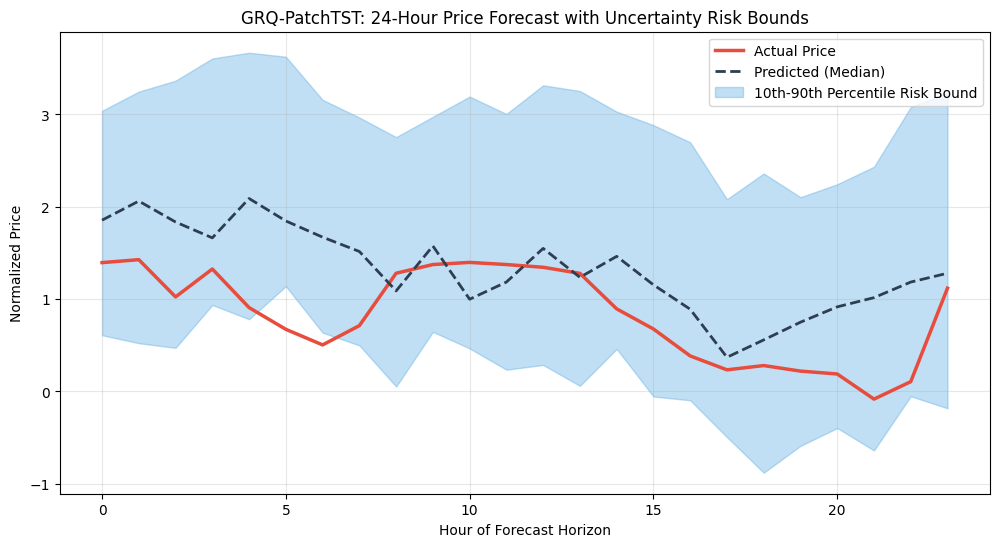

In [10]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Generating Risk Bound Visualization ---")

# 1. We need the full quantile predictions, not just the median
grq_model.eval()
all_preds_grq = []
all_actuals = []

with torch.no_grad():
    for x, y in test_loader:
        # out shape: (B, 24 horizon, 3 targets, 3 quantiles)
        out, _ = grq_model(x.to(device))
        all_preds_grq.append(out.cpu().numpy())
        all_actuals.append(y.numpy())

all_preds_grq = np.concatenate(all_preds_grq) # (Test_Size, 24, 3, 3)
all_actuals = np.concatenate(all_actuals)     # (Test_Size, 3, 24)

# 2. Pick a volatile window from your test set (Window 100 is usually a good random check,
# but you can loop through to find a spike)
WINDOW_IDX = 150 # Change this if the plot looks too flat
TARGET_IDX = 2   # Assuming Price is the 3rd target

actual_price = all_actuals[WINDOW_IDX, TARGET_IDX, :]
q10 = all_preds_grq[WINDOW_IDX, :, TARGET_IDX, 0]
q50 = all_preds_grq[WINDOW_IDX, :, TARGET_IDX, 1]
q90 = all_preds_grq[WINDOW_IDX, :, TARGET_IDX, 2]

# 3. Plot it
plt.figure(figsize=(12, 6))
x_axis = np.arange(24)

plt.plot(x_axis, actual_price, label="Actual Price", color="#e74c3c", linewidth=2.5)
plt.plot(x_axis, q50, label="Predicted (Median)", color="#2c3e50", linewidth=2, linestyle="--")
plt.fill_between(x_axis, q10, q90, color="#3498db", alpha=0.3, label="10th-90th Percentile Risk Bound")

plt.title(f"GRQ-PatchTST: 24-Hour Price Forecast with Uncertainty Risk Bounds")
plt.xlabel("Hour of Forecast Horizon")
plt.ylabel("Normalized Price")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

# Cell 8 — Summary Table